In [1]:
import dask.distributed
import folium
import folium.plugins
import geopandas as gpd
import shapely.geometry
from pystac_client import Client
import stackstac
import rioxarray as rio
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import planetary_computer 

from odc.stac import configure_rio, stac_load

In [2]:
client = dask.distributed.Client()
    
configure_rio(
    cloud_defaults = True, 
    aws = {"aws_unsigned": True},
    client = client
    )

display(client)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 16,Total memory: 62.57 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44781,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36249,Total threads: 4
Dashboard: http://127.0.0.1:41849/status,Memory: 15.64 GiB
Nanny: tcp://127.0.0.1:41239,


In [3]:
def db_scale(x):
    return 10 * np.log10(x)

In [4]:
gdf = gpd.read_file("./data/indigenous_protected_area.geojson")

gdf['area_km2'] = gdf.geometry.to_crs(epsg=6933).area / 10**6

In [5]:
# Total amount of protected area in km2.
gdf.area_km2.sum()

np.float64(1184768.1891703992)

In [6]:
target_pa = gdf[
    (gdf.area_km2 > 150) &
    (gdf.area_km2 < 175)
].sort_values(by='area_km2')

target_pa.iloc[0].terrai_nome

'Rio Pindaré'

In [7]:
pa = gdf[gdf.terrai_nome == 'Rio Pindaré']
pa_32723 = pa.to_crs(32723) #CRS of Xarray
pa_geom = target_pa.iloc[0].geometry
bbox = pa_32723.total_bounds

In [8]:
target_pa.iloc[0].geometry.exterior.coords, pa_geom, bbox

(<shapely.coords.CoordinateSequence at 0x7c7c42f8e250>,
 <POLYGON ((-45.505 -3.588, -45.505 -3.588, -45.504 -3.588, -45.504 -3.589, -...>,
 array([ 428577.35954176, 9591259.83398085,  456105.68769211,
        9607031.70086448]))

In [9]:
start_date = "2025-01-01"
end_date = "2025-02-28"

date_range = f"{start_date}/{end_date}"


filter_query = {'eo:cloud_cover': {'lt':50}}

In [ ]:
catalog = Client.open("https://earth-search.aws.element84.com/v1/")

query = catalog.search(
    collections=['sentinel-2-l2a',' sentinel-1-grd'],
    datetime = date_range,
    intersects=pa_geom,
    query = filter_query
)

items = list(query.items())

print(f"Found {len(items):d} datasets.")



Found 19 datasets.


In [ ]:
stac_json = query.item_collection_as_dict()

stac = gpd.GeoDataFrame.from_features(stac_json, "epsg:4326")

stac

,geometry,created,platform,constellation,instruments,eo:cloud_cover,proj:epsg,proj:centroid,mgrs:utm_zone,mgrs:latitude_band,...,s2:datatake_type,s2:datastrip_id,s2:reflectance_conversion_factor,datetime,s2:sequence,earthsearch:s3_path,earthsearch:payload_id,earthsearch:boa_offset_applied,processing:software,updated
0,"POLYGON ((-45.89999 -2.71385, -45.90086 -3.706...",2025-06-30T18:20:12.221Z,sentinel-2b,sentinel-2,[msi],49.789631,32723,"{'lat': -3.20062, 'lon': -45.41978}",23,M,...,INS-NOBS,S2B_OPER_MSI_L2A_DS_2BPS_20250630T171040_S2025...,0.967677,2025-06-30T13:33:11.946000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/23/M/M...,roda-sentinel2/workflow-sentinel2-to-stac/da9d...,True,{'sentinel2-to-stac': '2025.03.06'},2025-06-30T18:20:12.221Z
1,"POLYGON ((-45.90077 -3.61808, -45.90189 -4.610...",2025-06-20T18:23:52.859Z,sentinel-2b,sentinel-2,[msi],25.783163,32723,"{'lat': -4.09201, 'lon': -45.50093}",23,M,...,INS-NOBS,S2B_OPER_MSI_L2A_DS_2BPS_20250620T170147_S2025...,0.968910,2025-06-20T13:33:24.398000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/23/M/M...,roda-sentinel2/workflow-sentinel2-to-stac/3eea...,True,{'sentinel2-to-stac': '2025.03.06'},2025-06-20T18:23:52.859Z
2,"POLYGON ((-45.89999 -2.71385, -45.90086 -3.706...",2025-06-20T18:22:30.006Z,sentinel-2b,sentinel-2,[msi],46.248934,32723,"{'lat': -3.20144, 'lon': -45.41836}",23,M,...,INS-NOBS,S2B_OPER_MSI_L2A_DS_2BPS_20250620T170147_S2025...,0.968910,2025-06-20T13:33:09.913000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/23/M/M...,roda-sentinel2/workflow-sentinel2-to-stac/5fdd...,True,{'sentinel2-to-stac': '2025.03.06'},2025-06-20T18:22:30.006Z
3,"POLYGON ((-45.90077 -3.61808, -45.90189 -4.610...",2025-06-17T19:09:35.342Z,sentinel-2a,sentinel-2,[msi],19.774495,32723,"{'lat': -4.09219, 'lon': -45.49713}",23,M,...,INS-NOBS,S2A_OPER_MSI_L2A_DS_2APS_20250617T174922_S2025...,0.969457,2025-06-17T13:33:36.770000Z,1,s3://sentinel-cogs/sentinel-s2-l2a-cogs/23/M/M...,roda-sentinel2/workflow-sentinel2-to-stac/3087...,True,{'sentinel2-to-stac': '2025.03.06'},2025-06-17T19:09:35.342Z
4,"POLYGON ((-45.89999 -2.71385, -45.90086 -3.706...",2025-06-17T19:11:06.744Z,sentinel-2a,sentinel-2,[msi],27.067816,32723,"{'lat': -3.20246, 'lon': -45.41647}",23,M,...,INS-NOBS,S2A_OPER_MSI_L2A_DS_2APS_20250617T174922_S2025...,0.969457,2025-06-17T13:33:22.294000Z,1,s3://sentinel-cogs/sentinel-s2-l2a-cogs/23/M/M...,roda-sentinel2/workflow-sentinel2-to-stac/4950...,True,{'sentinel2-to-stac': '2025.03.06'},2025-06-17T19:11:06.744Z
5,"POLYGON ((-45.89999 -2.71385, -45.90086 -3.707...",2025-06-10T16:54:25.470Z,sentinel-2b,sentinel-2,[msi],43.227029,32723,"{'lat': -3.20263, 'lon': -45.41711}",23,M,...,INS-NOBS,S2B_OPER_MSI_L2A_DS_2BPS_20250610T152824_S2025...,0.971043,2025-06-10T13:33:07.697000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/23/M/M...,roda-sentinel2/workflow-sentinel2-to-stac/f47d...,True,{'sentinel2-to-stac': '2025.03.06'},2025-06-10T16:54:25.470Z
6,"POLYGON ((-45.90077 -3.61808, -45.90189 -4.611...",2025-06-07T19:12:04.017Z,sentinel-2a,sentinel-2,[msi],46.529195,32723,"{'lat': -4.09219, 'lon': -45.50496}",23,M,...,INS-NOBS,S2A_OPER_MSI_L2A_DS_2APS_20250607T174812_S2025...,0.971851,2025-06-07T13:33:39.799000Z,1,s3://sentinel-cogs/sentinel-s2-l2a-cogs/23/M/M...,roda-sentinel2/workflow-sentinel2-to-stac/5b8b...,True,{'sentinel2-to-stac': '2025.03.06'},2025-06-07T19:12:04.017Z
7,"POLYGON ((-45.89999 -2.71385, -45.90086 -3.706...",2025-06-07T19:15:04.801Z,sentinel-2a,sentinel-2,[msi],35.904396,32723,"{'lat': -3.20039, 'lon': -45.42004}",23,M,...,INS-NOBS,S2A_OPER_MSI_L2A_DS_2APS_20250607T174812_S2025...,0.971851,2025-06-07T13:33:25.314000Z,1,s3://sentinel-cogs/sentinel-s2-l2a-cogs/23/M/M...,roda-sentinel2/workflow-sentinel2-to-stac/928d...,True,{'sentinel2-to-stac': '2025.03.06'},2025-06-07T19:15:04.801Z
8,"POLYGON ((-45.90077 -3.61808, -45.90189 -4.610...",2025-06-05T17:30:04.887Z,sentinel-2c,sentinel-2,[msi],42.687356,32723,"{'lat': -4.09182, 'lon': -45.50697}",23,M,...,INS-NOBS,S2C_OPER_MSI_L2A_DS_2C

Text(0.5, 1.0, "Distribuition of Images' Cloud Cover")

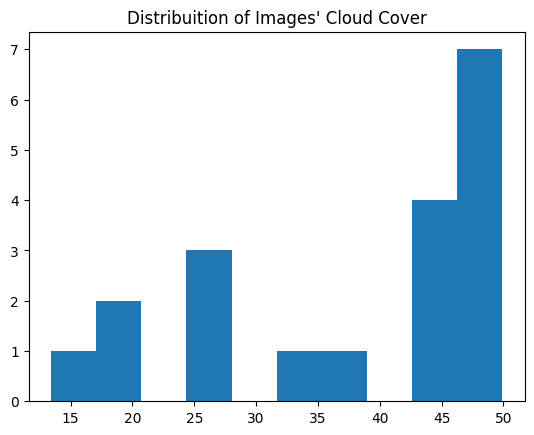

In [ ]:
plt.hist(stac['eo:cloud_cover'])
plt.title("Distribuition of Images' Cloud Cover")

In [ ]:
# Compute granule id from components
stac["granule"] = (
    stac["mgrs:utm_zone"].apply(lambda x: f"{x:02d}")
    + stac["mgrs:latitude_band"]
    + stac["mgrs:grid_square"]
)

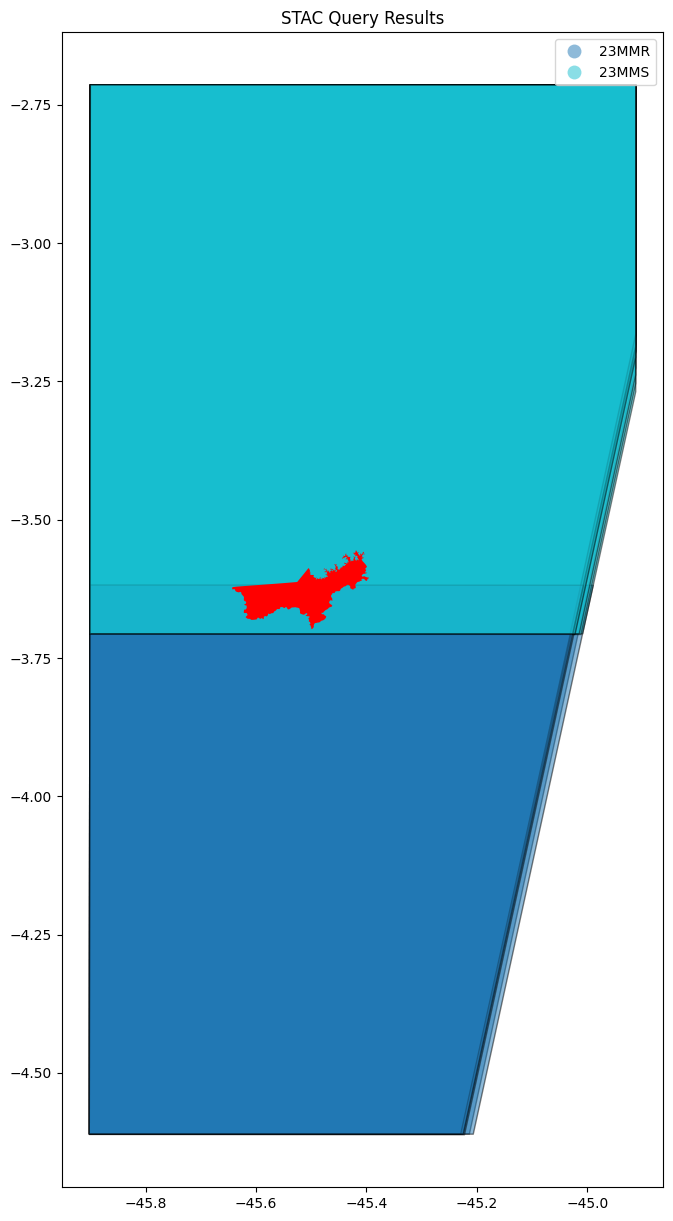

In [ ]:
fig = stac.plot(
    "granule",
    edgecolor='black',
    categorical = True,
    aspect = "equal",
    alpha = 0.5,
    figsize=(12,15),
    legend = True
    )

pa.plot(color = "red", ax = fig)

__ = fig.set_title('STAC Query Results')

In [ ]:
data = stac_load(
    items,
    bands = ['red','green','blue', 'nir'],
    resolution = 10,
    crs = 'utm',
    chunks = {},
    groupby='solar_day',
    intersects=pa_geom
).compute()

In [ ]:
data

<xarray.Dataset> Size: 452MB
Dimensions:      (y: 1579, x: 2754, time: 13)
Coordinates:
  * y            (y) float64 13kB 9.607e+06 9.607e+06 ... 9.591e+06 9.591e+06
  * x            (x) float64 22kB 4.286e+05 4.286e+05 ... 4.561e+05 4.561e+05
  * time         (time) datetime64[ns] 104B 2025-04-08T13:33:22.127000 ... 20...
    spatial_ref  int32 4B 32723
Data variables:
    red          (time, y, x) uint16 113MB 760 858 778 662 ... 922 594 323 294
    green        (time, y, x) uint16 113MB 1168 1152 1050 865 ... 692 553 674
    blue         (time, y, x) uint16 113MB 1026 977 875 794 ... 628 482 268 338
    nir          (time, y, x) uint16 113MB 3432 3388 3000 ... 2830 3580 4144

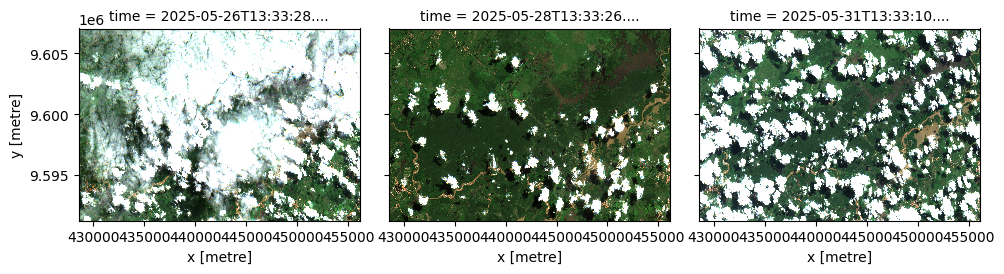

In [ ]:
def plot_rgb(data):
    rgb = data[["red", "green", "blue"]]

    rgb_subset = rgb.isel(time=slice(4, 7)).to_array()

    rgb_subset.plot.imshow(
    col="time",
    col_wrap=3,
    vmin=0,
    vmax=2000
    )

plot_rgb(data=data)

In [ ]:
pa.to_crs(32723, inplace = True)

/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [ ]:
geometries = pa_32723.geometry.values.tolist()
#clipping the datacube according to the geometry and keeping the same CRS
clipped = data.rio.clip(geometries)

In [ ]:
clipped

<xarray.Dataset> Size: 452MB
Dimensions:      (y: 1577, x: 2753, time: 13)
Coordinates:
  * y            (y) float64 13kB 9.607e+06 9.607e+06 ... 9.591e+06 9.591e+06
  * x            (x) float64 22kB 4.286e+05 4.286e+05 ... 4.561e+05 4.561e+05
  * time         (time) datetime64[ns] 104B 2025-04-08T13:33:22.127000 ... 20...
    spatial_ref  int64 8B 0
Data variables:
    red          (time, y, x) uint16 113MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    green        (time, y, x) uint16 113MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    blue         (time, y, x) uint16 113MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    nir          (time, y, x) uint16 113MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0

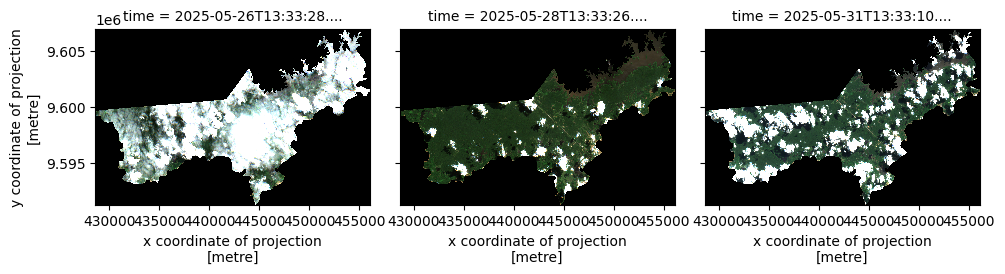

In [ ]:
plot_rgb(clipped)

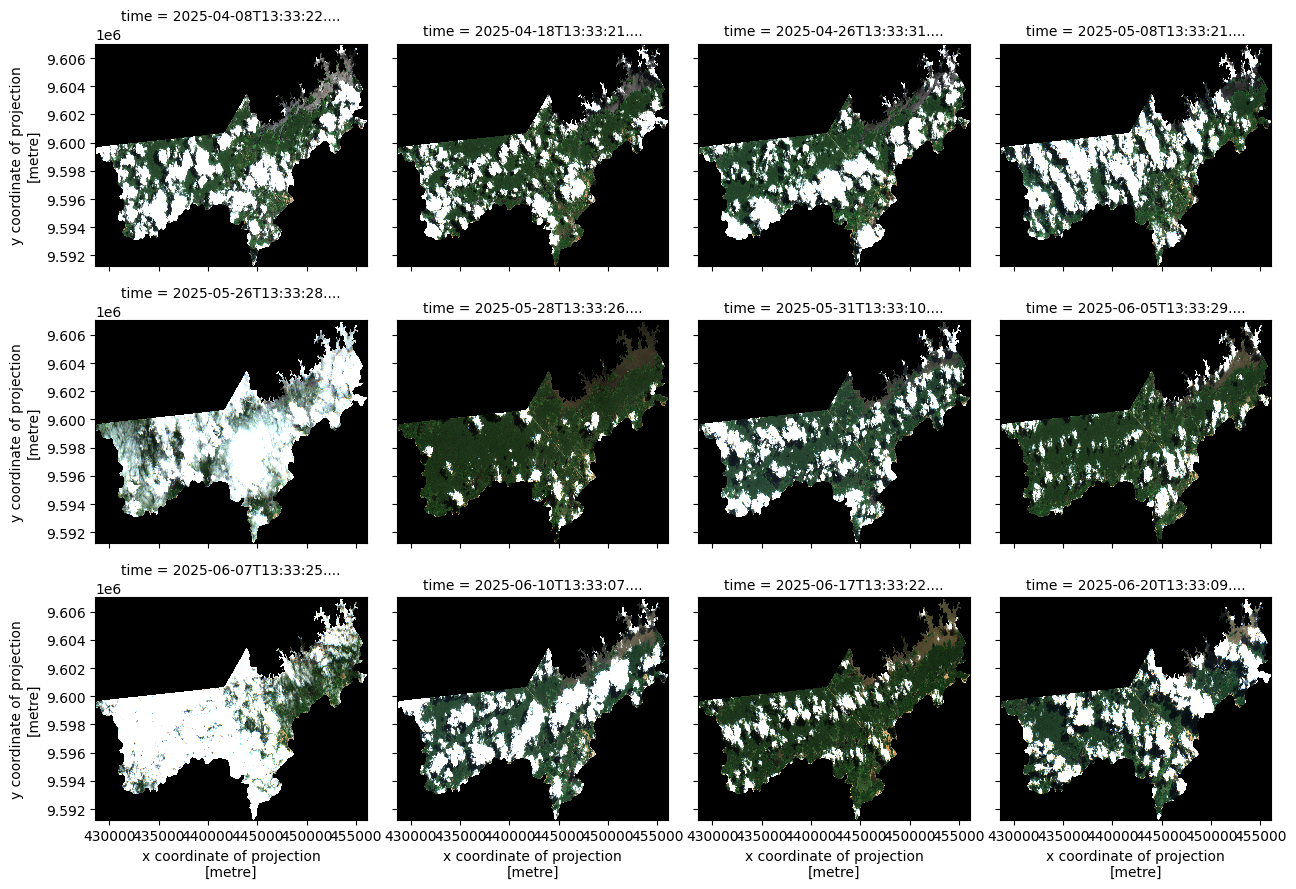

In [ ]:
rgb = clipped[["red", "green", "blue"]]

rgb_subset = rgb.isel(time=slice(0, -1)).to_array()

rgb_subset.plot.imshow(
    col="time",
    col_wrap=4,
    vmin=0,
    vmax=2000
)

### Sentinel-1 from MPC

In [30]:
date_range

'2025-01-01/2025-02-28'

In [10]:
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier = planetary_computer.sign_inplace
    )

query = catalog.search(
    collections=["sentinel-1-rtc"],
    datetime = '2025-01-01/2025-06-30',
    intersects=pa_geom
)

items = list(query.items())

print(f"Found {len(items):d} datasets.")



Found 15 datasets.


In [11]:
#Loading STAC to Xarray

s1_cube = stac_load(
    items,
    bands = ['vv', 'vh'],
    intersects=pa_geom,
    resolution = 30, 
    chunks = {},
    preserve_original_order=True,
    groupby = 'solar_day' 
)

#s1_cube = s1_cube.where(s1_cube != -32768)

In [12]:
#clipping the datacube according to the geometry and keeping the same CRS

geometries = pa_32723.geometry.values.tolist()
s1_clipped = s1_cube.rio.clip(geometries)

In [13]:
# Applying db scale conversion to VV and VH bands
for band in s1_clipped.data_vars:
    s1_clipped[band] = db_scale(s1_clipped[band])

In [14]:
s1_clipped

<xarray.Dataset> Size: 58MB
Dimensions:      (y: 525, x: 918, time: 15)
Coordinates:
  * y            (y) float64 4kB 9.607e+06 9.607e+06 ... 9.591e+06 9.591e+06
  * x            (x) float64 7kB 4.286e+05 4.286e+05 ... 4.561e+05 4.561e+05
  * time         (time) datetime64[ns] 120B 2025-01-06T08:42:23.375812 ... 20...
    spatial_ref  int64 8B 0
Data variables:
    vv           (time, y, x) float32 29MB dask.array<chunksize=(1, 525, 918), meta=np.ndarray>
    vh           (time, y, x) float32 29MB dask.array<chunksize=(1, 525, 918), meta=np.ndarray>

/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)


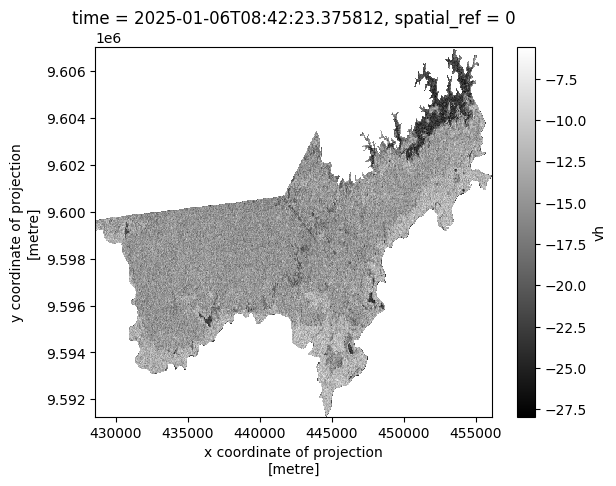

In [ ]:
s1_clipped.vh.isel(time=0).plot(cmap = 'grey', robust = True)

In [15]:
s1_clipped['vv_vh_ratio'] = s1_clipped['vv'] / s1_clipped['vh']
s1_clipped['rvi'] = (s1_clipped['vh'] * 4)/ s1_clipped['vv'] + s1_clipped['vh']

/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)


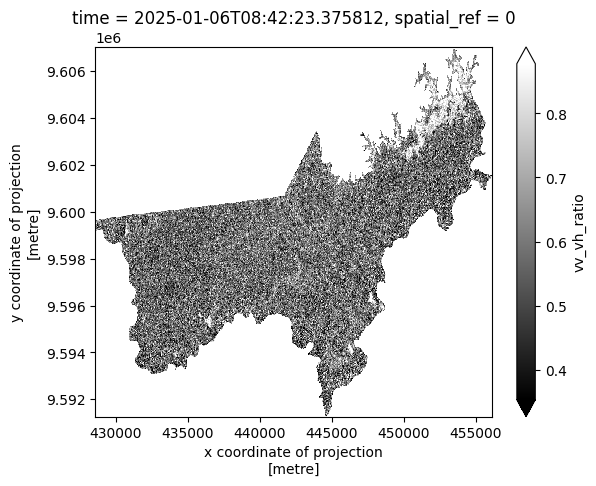

In [16]:
s1_clipped['vv_vh_ratio'].isel(time=0).plot(cmap = 'grey', robust = True)

/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)


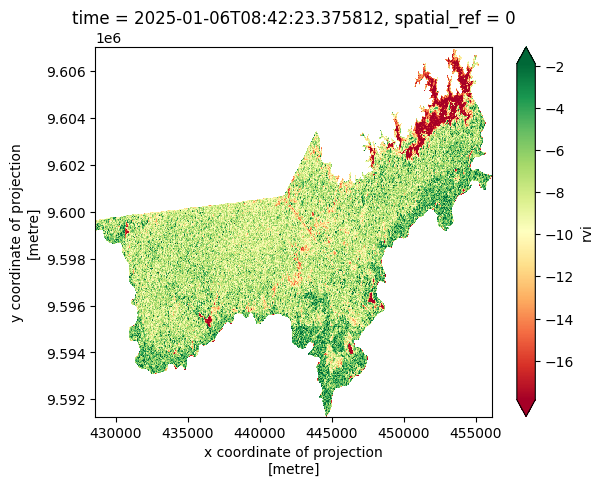

In [66]:
s1_clipped['rvi'].isel(time=0).plot(cmap = 'RdYlGn', robust = True)

/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)


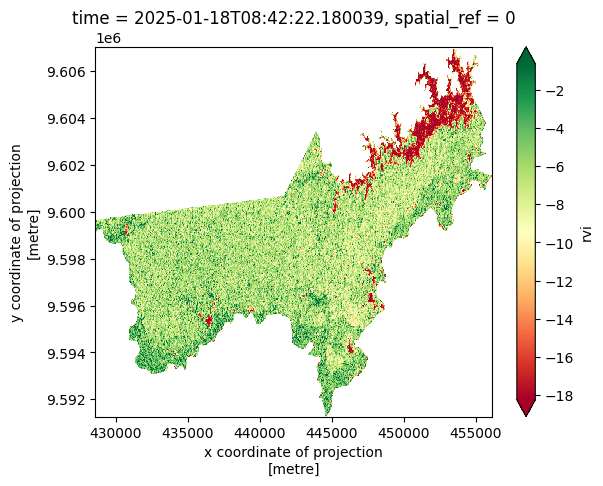

In [65]:
s1_clipped['rvi'].isel(time=1).plot(cmap = 'RdYlGn', robust = True)

In [17]:
scene_da = s1_clipped.to_array('band')
scene_da

<xarray.DataArray (band: 4, time: 15, y: 525, x: 918)> Size: 116MB
dask.array<stack, shape=(4, 15, 525, 918), dtype=float32, chunksize=(1, 1, 525, 918), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) object 32B 'vv' 'vh' 'vv_vh_ratio' 'rvi'
  * time         (time) datetime64[ns] 120B 2025-01-06T08:42:23.375812 ... 20...
  * y            (y) float64 4kB 9.607e+06 9.607e+06 ... 9.591e+06 9.591e+06
  * x            (x) float64 7kB 4.286e+05 4.286e+05 ... 4.561e+05 4.561e+05
    spatial_ref  int64 8B 0

/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)
/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)


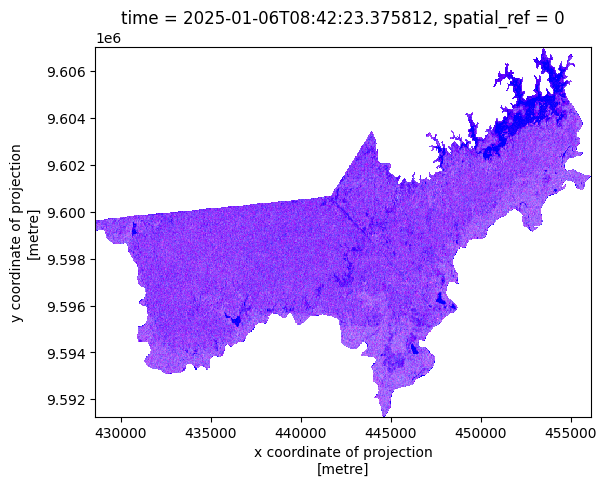

In [23]:
scene_da.sel(band = ['vv', 'vh', 'vv_vh_ratio'])\
        .isel(time = 0)\
        .plot.\
        imshow(robust = True)

/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)
/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)


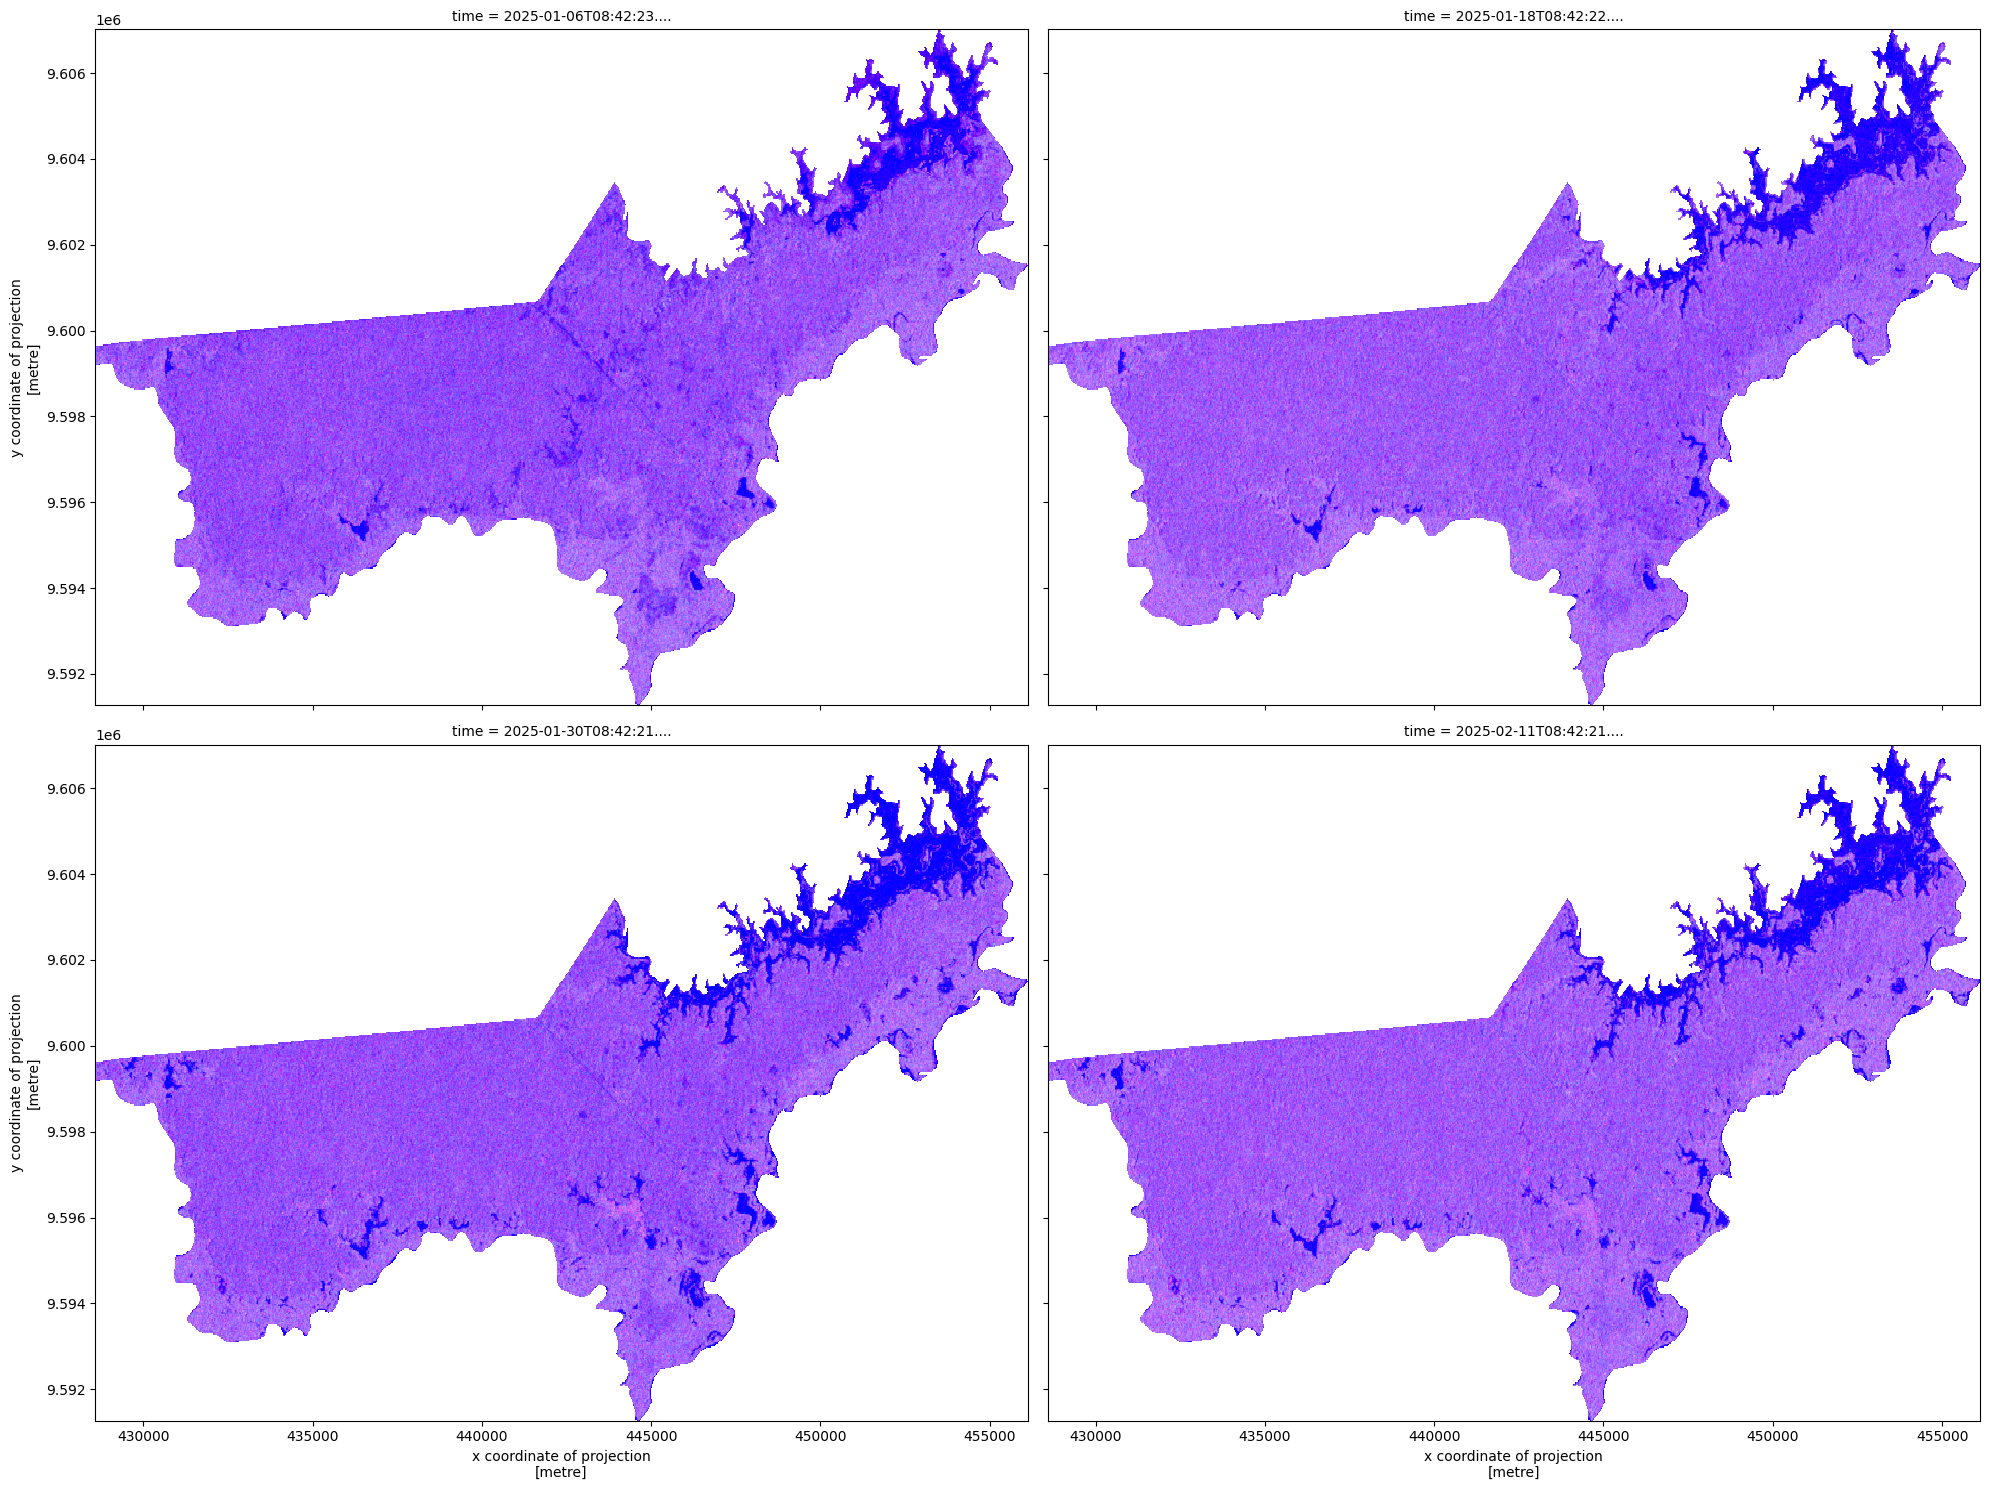

In [29]:
scene_da.sel(band = ['vv', 'vh', 'vv_vh_ratio'])\
        .isel(time=slice(0, -1))\
        .plot.\
        imshow(
            robust = True,
            col = 'time',
            col_wrap = 2,
            figsize = (20,15)
            )


In [18]:
monthly_data = s1_clipped.resample(time = 'W').mean()

monthly_data

<xarray.Dataset> Size: 193MB
Dimensions:      (y: 525, x: 918, time: 25)
Coordinates:
  * y            (y) float64 4kB 9.607e+06 9.607e+06 ... 9.591e+06 9.591e+06
  * x            (x) float64 7kB 4.286e+05 4.286e+05 ... 4.561e+05 4.561e+05
  * time         (time) datetime64[ns] 200B 2025-01-12 2025-01-19 ... 2025-06-29
    spatial_ref  int64 8B 0
Data variables:
    vv           (time, y, x) float32 48MB dask.array<chunksize=(1, 525, 918), meta=np.ndarray>
    vh           (time, y, x) float32 48MB dask.array<chunksize=(1, 525, 918), meta=np.ndarray>
    vv_vh_ratio  (time, y, x) float32 48MB dask.array<chunksize=(1, 525, 918), meta=np.ndarray>
    rvi          (time, y, x) float32 48MB dask.array<chunksize=(1, 525, 918), meta=np.ndarray>

In [19]:
diff = monthly_data['rvi'].isel(time = -1) - monthly_data['rvi'].isel(time = 0)
diff

<xarray.DataArray 'rvi' (y: 525, x: 918)> Size: 2MB
dask.array<sub, shape=(525, 918), dtype=float32, chunksize=(525, 918), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 4kB 9.607e+06 9.607e+06 ... 9.591e+06 9.591e+06
  * x            (x) float64 7kB 4.286e+05 4.286e+05 ... 4.561e+05 4.561e+05
    spatial_ref  int64 8B 0

/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)
/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)


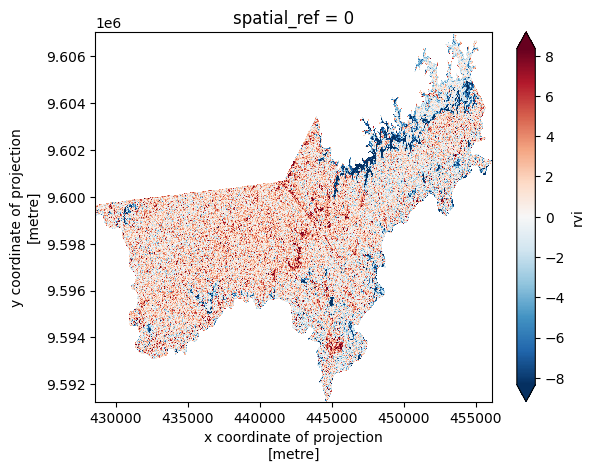

In [64]:
diff.plot(robust = True)

In [20]:
from datetime import datetime
import pandas as pd
initial_date = pd.to_datetime(str(np.array(monthly_data.coords['time'][0]))).strftime('%Y-%m-%d')
final_date = pd.to_datetime(str(np.array(monthly_data.coords['time'][-1]))).strftime('%Y-%m-%d')

/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)
/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)
/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)
/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)


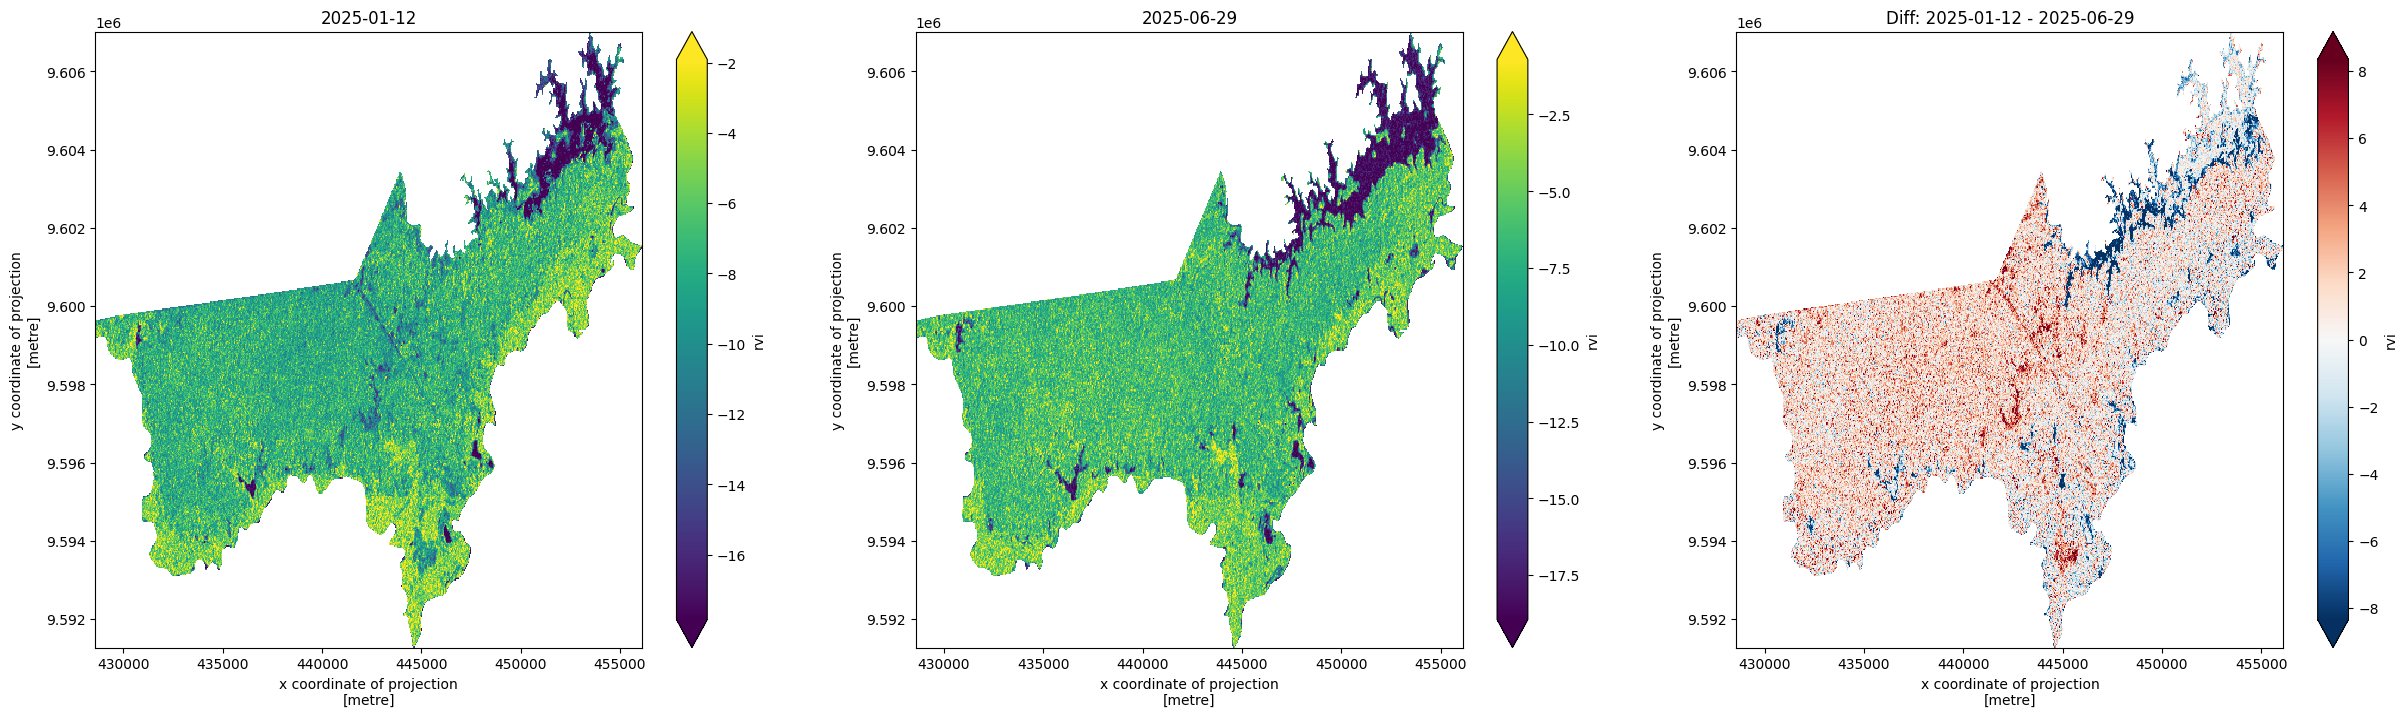

In [21]:
fig, ax = plt.subplots(ncols = 3, nrows = 1, figsize = (30, 8))


monthly_data['rvi']\
    .isel(time = 0)\
    .plot(robust = True, ax = ax[0])

ax[0].set_title(initial_date)

monthly_data['rvi']\
    .isel(time = -1)\
    .plot(robust = True, ax = ax[1])

ax[1].set_title(final_date)

diff.plot(robust = True, ax = ax[2])
ax[2].set_title(f'Diff: {initial_date} - {final_date}')

plt.show()


/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)


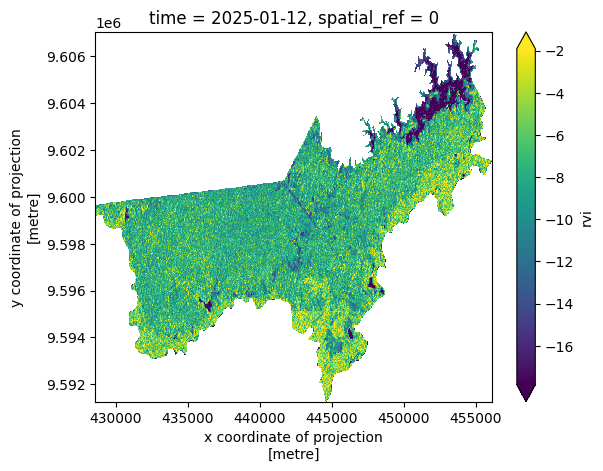

In [52]:
monthly_data['rvi'].isel(time = 0).plot(robust = True)

In [22]:
ts_rvi = s1_clipped['rvi'].to_dataframe().dropna()
ts_vv = s1_clipped['vv'].to_dataframe().dropna()
ts_vh = s1_clipped['vh'].to_dataframe().dropna()
ts_vvvh = s1_clipped['vv_vh_ratio'].to_dataframe().dropna()

/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)
/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)
/home/rodrigo.santos/Documents/git/00_pe

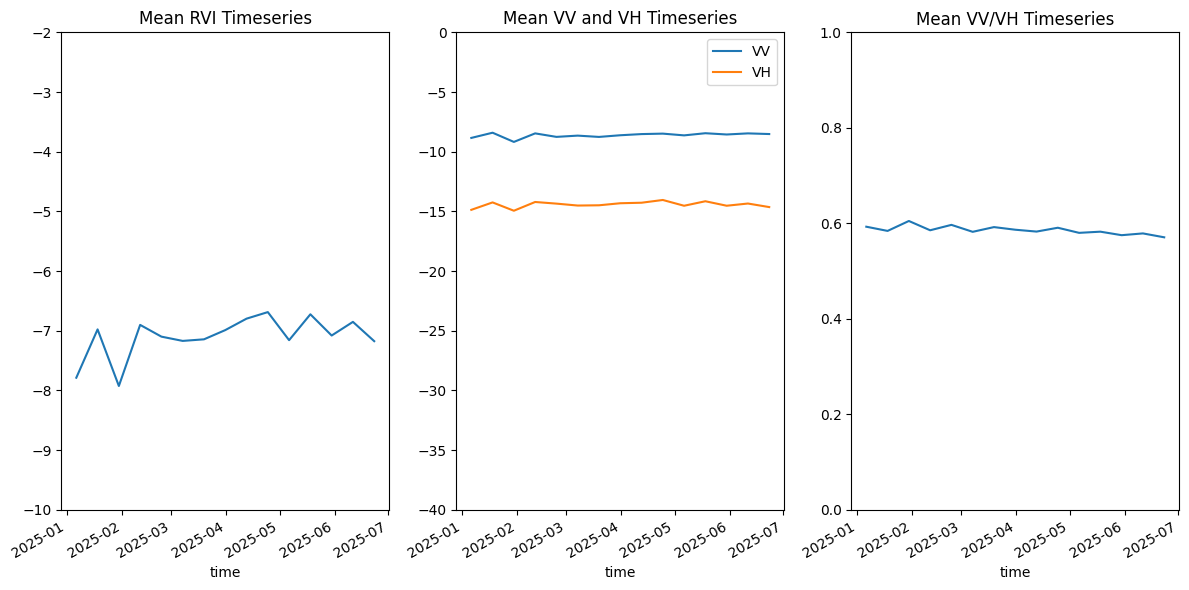

In [23]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 6))

ts_rvi.groupby('time')['rvi'].mean().plot(ax = axs[0], title = 'Mean RVI Timeseries')
axs[0].set_ylim(-10, -2)

ts_vv.groupby('time')['vv'].mean().plot(ax = axs[1], title = 'Mean VV and VH Timeseries')
ts_vh.groupby('time')['vh'].mean().plot(ax = axs[1])
axs[1].legend(['VV', 'VH'])
axs[1].set_ylim(-40,0)


ts_vvvh.groupby('time')['vv_vh_ratio'].mean().plot(ax = axs[2], title = 'Mean VV/VH Timeseries')
axs[2].set_ylim(0, 1)


plt.tight_layout()
plt.show()

In [27]:
ts_vvvh.groupby('time')['vv_vh_ratio'].mean().to_csv('./data/vv_vh_ratio_timeseries.csv')
ts_rvi.groupby('time')['rvi'].mean().to_csv('./data/rvi_timeseries.csv')
ts_vv.groupby('time')['vv'].mean().to_csv('./data/vv_timeseries.csv')
ts_vh.groupby('time')['vh'].mean().to_csv('./data/vh_timeseries.csv')

In [28]:
s1_clipped.to_zarr('./DC_S1_GRD_01012025_06302025.zarr', mode = 'w')

/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)
/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)
/home/rodrigo.santos/Documents/git/00_personal_projects/protected_areas_etl/.venv/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)


In [29]:
s1_zarr = xr.open_dataset(
    './DC_S1_GRD_01012025_06302025.zarr',
    engine = 'zarr'
    )
s1_zarr

<xarray.Dataset> Size: 116MB
Dimensions:      (time: 15, y: 525, x: 918)
Coordinates:
  * time         (time) datetime64[ns] 120B 2025-01-06T08:42:23.375812 ... 20...
  * y            (y) float64 4kB 9.607e+06 9.607e+06 ... 9.591e+06 9.591e+06
  * x            (x) float64 7kB 4.286e+05 4.286e+05 ... 4.561e+05 4.561e+05
    spatial_ref  int64 8B ...
Data variables:
    rvi          (time, y, x) float32 29MB ...
    vh           (time, y, x) float32 29MB ...
    vv           (time, y, x) float32 29MB ...
    vv_vh_ratio  (time, y, x) float32 29MB ...